In [ ]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import TensorDataset
import torch.nn as nn
from torch import optim
import matplotlib.pyplot as plt
import seaborn as sns

# Training a Neural Network with PyTorch

## Data Loaders


`TensorDataset`: It combines your input features (X) and labels (y) into a single dataset object. This makes it easy to handle and access individual samples as pairs of inputs and labels

`DataLoader`: It takes the TensorDataset and helps load data in small groups called batches. It also shuffles data if needed, which helps the model learn better by seeing data in different orders each epoch.

`batch_size`: is the number of samples to process in each iteration

`shuffle`: Randomizes the order of samples in each epoch

`Epoch`: One full pass through the training dataloader

`Generalization`: The ability of a model to perform well on unseen data


**Using TensorDataset**

Structuring your data into a dataset is one of the first steps in training a PyTorch neural network. `TensorDataset` simplifies this by converting NumPy arrays into a format PyTorch can use.

In this exercise, you'll create a `TensorDataset` using the preloaded `animals` dataset and inspect its structure.


In [46]:
# animal dataset
X = np.array([[0, 1, 1, 0, 0, 2, 1],
       [0, 1, 1, 0, 1, 2, 1],
       [1, 0, 0, 1, 1, 4, 1],
       [1, 0, 0, 1, 0, 4, 1],
       [0, 0, 1, 0, 1, 4, 1]])
y = np.array([0, 0, 1, 1, 2])
animals = pd.DataFrame(X)
animals['label'] = y

In [47]:
X = animals.iloc[:, 1:-1].to_numpy()  
y = animals.iloc[:, -1].to_numpy()

# Create a dataset
dataset = TensorDataset(torch.tensor(X).float(), torch.tensor(y).float())

# Print the first sample
input_sample, label_sample = dataset[0]
print('Input sample:', input_sample)
print('Label sample:', label_sample)

Input sample: tensor([1., 1., 0., 0., 2., 1.])
Label sample: tensor(0.)


**Using DataLoader**

The `DataLoader` class is essential for efficiently handling large datasets. It speeds up training, optimizes memory usage, and stabilizes gradient updates, making deep learning models more effective.

Now, you'll create a PyTorch `DataLoader` using the `dataset` from the previous exercise and see it in action.


In [48]:
from torch.utils.data import DataLoader

# Create a DataLoader
dataloader = DataLoader(dataset,batch_size=2,shuffle=True)

# Iterate over the dataloader
for batch_inputs, batch_labels in dataloader:
    print('batch_inputs:', batch_inputs)
    print('batch_labels:', batch_labels)

batch_inputs: tensor([[0., 1., 0., 1., 4., 1.],
        [0., 0., 1., 1., 4., 1.]])
batch_labels: tensor([2., 1.])
batch_inputs: tensor([[1., 1., 0., 0., 2., 1.],
        [0., 0., 1., 0., 4., 1.]])
batch_labels: tensor([0., 1.])
batch_inputs: tensor([[1., 1., 0., 1., 2., 1.]])
batch_labels: tensor([0.])


## Training a NN


**Using the MSELoss**

For regression problems, you often use Mean Squared Error (MSE) as a loss function instead of cross-entropy. MSE calculates the squared difference between predicted values (`y_pred`) and actual values (`y`). Now, you'll compute MSE loss using both NumPy and PyTorch.

`torch`, `numpy` (as `np`), and `torch.nn` (as `nn`) packages are already imported.


In [49]:
y_pred = np.array([3, 5.0, 2.5, 7.0])  
y = np.array([3.0, 4.5, 2.0, 8.0])     

# Calculate MSE using NumPy
mse_numpy = np.mean((y_pred-y)**2)

# Create the MSELoss function in PyTorch
criterion = nn.MSELoss()

# Calculate MSE using PyTorch
mse_pytorch = criterion(torch.tensor(y_pred), torch.tensor(y))

print("MSE (NumPy):", mse_numpy)
print("MSE (PyTorch):", mse_pytorch)

MSE (NumPy): 0.375
MSE (PyTorch): tensor(0.3750, dtype=torch.float64)


Writing a training loop

In `scikit-learn`, the training loop is wrapped in the `.fit()` method, while in PyTorch, it's set up manually. While this adds flexibility, it requires a custom implementation.

In this exercise, you'll create a loop to train a model for salary prediction.

The `show_results()` function is provided to help you visualize some sample predictions.

The package imports provided are: `pandas as pd`, `torch`, `torch.nn as nn`, `torch.optim as optim`, as well as `DataLoader` and `TensorDataset` from `torch.utils.data`.

The following variables have been created: `num_epochs`, containing the number of epochs (set to 5); `dataloader`, containing the dataloader; `model`, containing the neural network; `criterion`, containing the loss function, `nn.MSELoss()`; `optimizer`, containing the SGD optimizer.


In [50]:
# Loop over the number of epochs and the dataloader
num_epochs = 4
model = nn.Sequential(
    nn.Linear(X.shape[1], 3),
    nn.Linear(3, 1)
)
optimizer = optim.SGD(model.parameters(), lr=0.01)

In [51]:
def show_results(model, dataloader):
  for i in range(num_epochs):
    for data in dataloader:
      # Set the gradients to zero
      optimizer.zero_grad()
      # Run a forward pass
      feature, target = data
      prediction = model(feature)    
      # Compute the loss
      loss = criterion(prediction, target)    
      # Compute the gradients
      loss.backward()
      # Update the model's parameters
      optimizer.step()
      
      print(f'Epoch: {i}, Loss: {loss.item()}')
show_results(model, dataloader)

Epoch: 0, Loss: 5.907493591308594
Epoch: 0, Loss: 0.11452771723270416
Epoch: 0, Loss: 1.7364747524261475
Epoch: 1, Loss: 1.496994972229004
Epoch: 1, Loss: 0.346826434135437
Epoch: 1, Loss: 0.7859248518943787
Epoch: 2, Loss: 0.285230427980423
Epoch: 2, Loss: 1.1446709632873535
Epoch: 2, Loss: 0.3453443646430969
Epoch: 3, Loss: 0.31153327226638794
Epoch: 3, Loss: 1.0652798414230347
Epoch: 3, Loss: 0.24864524602890015


/home/shk/.local/lib/python3.14/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([2])) that is different to the input size (torch.Size([2, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/home/shk/.local/lib/python3.14/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([1, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


## ReLU activation functions

### ReLU

- ReLU is used in the hidden layers
- Sigmoid and Softmax is not good in the hidden layers but the output layer
- `f(x) = max(0, x)`
- Helps overcome **vanishing gradients**


#### Leaky ReLU

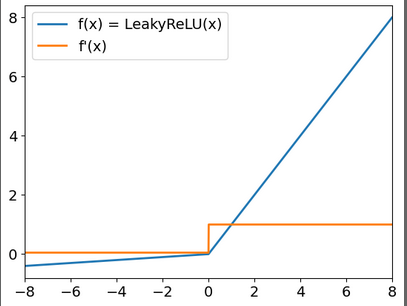


**Implementing ReLU**

The Rectified Linear Unit (ReLU) is a widely-used activation function in deep learning, solving challenges like the vanishing gradients problem.

In this exercise, you'll implement ReLU in PyTorch, apply it to both positive and negative values, and observe the results.

`torch.nn` package has already been imported for you as `nn`.


In [52]:
# Create a ReLU function with PyTorch
relu_pytorch = nn.ReLU()

x_pos = torch.tensor(2.0)
x_neg = torch.tensor(-3.0)

# Apply the ReLU function to the tensors
output_pos = relu_pytorch(x_pos)
output_neg = relu_pytorch(x_neg)

print("ReLU applied to positive value:", output_pos)
print("ReLU applied to negative value:", output_neg)

ReLU applied to positive value: tensor(2.)
ReLU applied to negative value: tensor(0.)


**Implementing leaky ReLU**

While ReLU is widely used, it sets negative inputs to 0, resulting in null gradients for those values. This can prevent parts of the model from learning.

Leaky ReLU overcomes this by allowing small gradients for negative inputs, controlled by the negative_slope parameter. Instead of 0, negative inputs are scaled by this small value, keeping the model's learning active.

In this exercise, you will implement the leaky ReLU function in PyTorch and practice using it. `torch` package as well as the `torch.nn` as `nn` have already been imported.


In [53]:
# Create a leaky relu function in PyTorch
leaky_relu_pytorch = nn.LeakyReLU(negative_slope=0.05)

x = torch.tensor(-3.0)
# Call the above function on the tensor x
output = leaky_relu_pytorch(x)
print(output)

tensor(-0.1500)


## Learning rate and momentum


- Training a nn = solving an optimization problem.


In [54]:
sgd = optim.SGD(model.parameters(),lr=0.01,momentum=0.95)

- `lr`: Learning rate which controls the step size
- `momentum`: adds inertia to avoid getting stuck
- with momentum we can get to the global minimum faster


**Experimenting with learning rate**

In this exercise, your goal is to find the optimal learning rate such that the optimizer can find the minimum of the non-convex function in ten steps.

You will experiment with three different learning rate values. For this problem, try learning rate values between 0.001 to 0.1.

You are provided with the optimize_and_plot() function that takes the learning rate for the first argument. This function will run 10 steps of the SGD optimizer and display the results.


In [69]:
def optimize_and_plot(lr=0.01, momentum=0.0):
    x = torch.tensor(2.0, requires_grad=True)
    buffer = torch.zeros_like(x.data)
    values = []
    def function(x):
        if isinstance(x, torch.Tensor):
            return x**4 + x**3 - 5*x**2
        else:
            return x**4 + x**3 - 5*x**2
    for i in range(20):
        y = function(x)
        values.append((x.clone(), y.clone()))
        y.backward()
        d_p = x.grad.data
        if momentum != 0:
            buffer.mul_(momentum).add_(d_p)
            d_p = buffer
        x.data.add_(d_p, alpha=-lr)
        x.grad.zero_()
    x_plot = np.arange(-3, 2, 0.001)
    y_plot = function(x_plot)
    plt.figure(figsize=(10, 5))
    plt.plot([v[0].detach().numpy() for v in values],  # Detach tensors here
             [v[1].detach().numpy() for v in values], 'r-X',
             linewidth=2, markersize=7)
    for i in range(10):
        plt.text(values[i][0].detach().numpy() + 0.1,  # Detach tensors here
                 values[i][1].detach().numpy(),       # Detach tensors here
                 f'step {i}', fontdict={'color': 'r'})
    plt.plot(x_plot, y_plot, linewidth=2)
    plt.grid()
    plt.tick_params(axis='both', which='major', labelsize=12)
    plt.legend(['Optimizer steps', 'Function'])
    plt.show()


Try a small learning rate value such that the optimizer isn't able to get past the first minimum on the right.


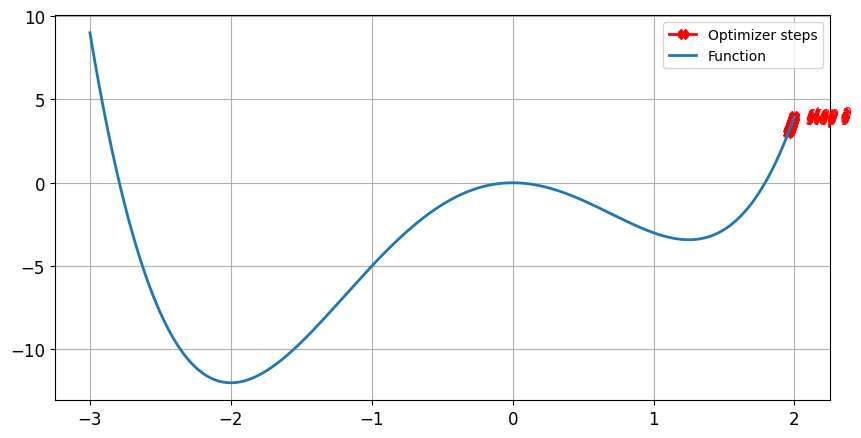

In [70]:
# Try a first learning rate value
lr0 = 0.0001
optimize_and_plot(lr=lr0)

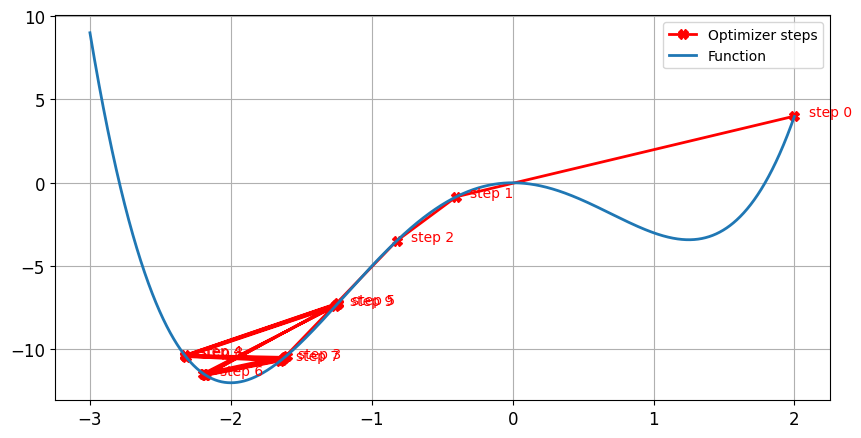

In [71]:
# Try a large lr
lr0 = 0.1
optimize_and_plot(lr=lr0)

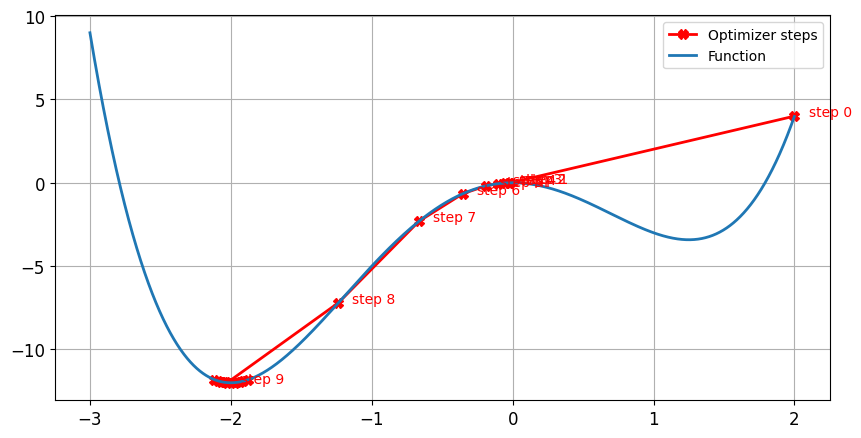

In [88]:
# Try a good lr
lr0 = 0.084
optimize_and_plot(lr=lr0)

**momentum**


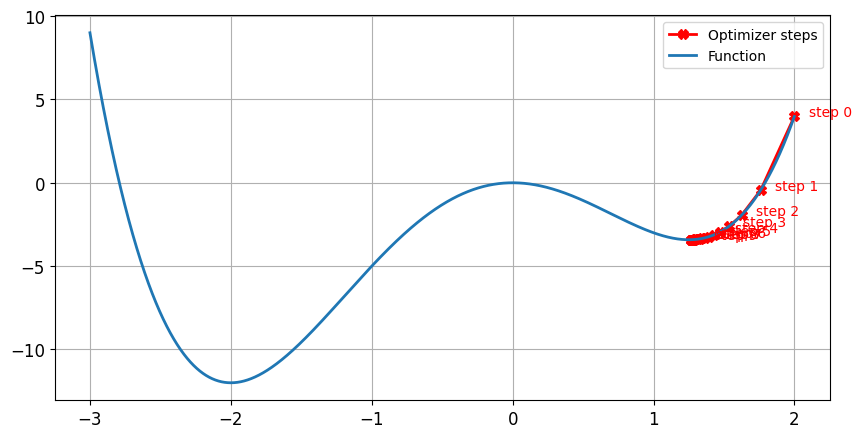

In [89]:
# Try a first value for momentum
mom0 = 0
optimize_and_plot(momentum=mom0)

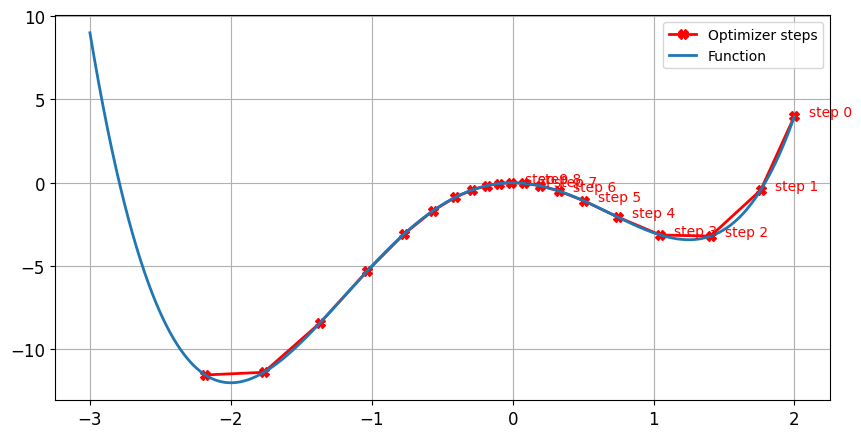

In [90]:
# Try a second value for momentum
mom1 = 0.92
optimize_and_plot(momentum=mom1)

# Evaluating and Improving Models

## Layer initialization and transfer learning


- Neural network weights are initialized to small values for stability.
- Layer initialization can be done using PyTorch's nn.init module.
- Transfer learning reuses a pre-trained model's weights for a new task.
- Saving and loading weights is done with torch.save and torch.load.
- Fine-tuning involves training a loaded model with a smaller learning rate.
- You can freeze layers by setting requires_grad to False to prevent them from updating during training.


### Fine tunning pipeline

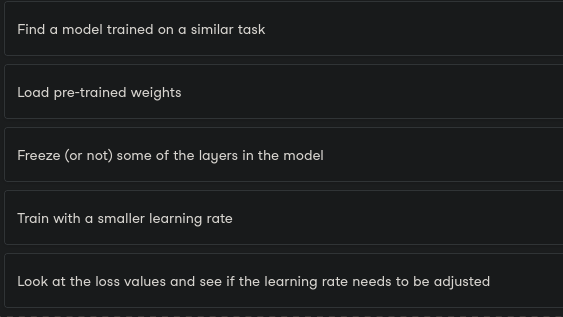


**Freeze layers of a model**

You are about to fine-tune a model on a new task after loading pre-trained weights. The model contains three linear layers. However, because your dataset is small, you only want to train the last linear layer of this model and freeze the first two linear layers.

The model has already been created and exists under the variable model. You will be using the named_parameters method of the model to list the parameters of the model. Each parameter is described by a name. This name is a string with the following naming convention: x.name where x is the index of the layer.

Remember that a linear layer has two parameters: the weight and the bias.


In [91]:
for name, param in model.named_parameters():
  
    # Check for first layer's weight
    if name == '0.weight':
   
        # Freeze this weight
        param.requires_grad = False
        
    # Check for second layer's weight
    if name == '1.weight':
      
        # Freeze this weight
        param.requires_grad = False

**Layer initialization**

The initialization of the weights of a neural network has been the focus of researchers for many years. When training a network, the method used to initialize the weights has a direct impact on the final performance of the network.

As a machine learning practitioner, you should be able to experiment with different initialization strategies. In this exercise, you are creating a small neural network made of two layers and you are deciding to initialize each layer's weights with the uniform method.


In [96]:
layer0 = nn.Linear(16, 32)
layer1 = nn.Linear(32, 64)

# Use uniform initialization for layer0 and layer1 weights
nn.init.uniform_(layer0.weight)
nn.init.uniform_(layer1.weight)

model = nn.Sequential(layer0, layer1)

## Evaluating model performance


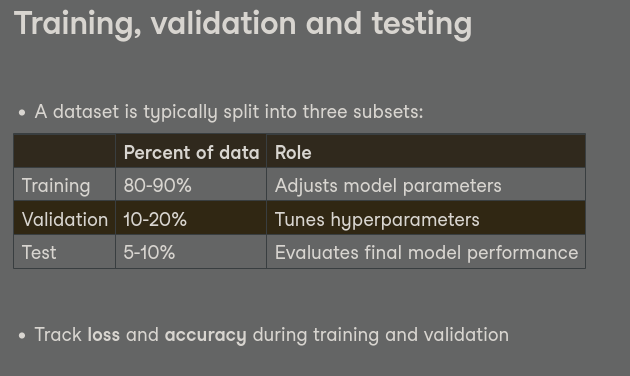


- Validation helps us detect **Overfitting**
- When the training loss start to decrease and the validation increase this means is overfitting


**Writing the evaluation loop**

In this exercise, you will write an evaluation loop to compute validation loss. The evaluation loop follows a similar structure to the training loop but without gradient calculations or weight updates.

`model`, `validationloader`, and loss function `criterion` have already been defined to handle predictions, data loading, and loss calculation.


In [ ]:
# Set the model to evaluation mode
model.eval()
validation_loss = 0.0

with torch.no_grad():
  for features, labels in validationloader:
      outputs = model(features)
      loss = criterion(outputs, labels)
      # Sum the current loss to the validation_loss variable
      validation_loss += loss.item()
      
# Calculate the mean loss value
validation_loss_epoch = validation_loss/len(validationloader)
print(validation_loss_epoch)

# Set the model back to training mode
model.train()

**Calculating accuracy using torchmetrics**

Tracking accuracy during training helps identify the best-performing epoch.

In this exercise, you'll use `torchmetrics` to calculate accuracy on a facemask dataset with three classes. The `plot_errors` function will highlight misclassified samples, helping you analyze model errors.

`torchmetrics` package is already imported. Model `outputs` are softmax probabilities, and `labels` are one-hot encoded vectors.


In [ ]:
# Create accuracy metric
metric = torchmetrics.Accuracy(task="multiclass", num_classes=3)
for features, labels in dataloader:
    outputs = model(features)
    
    # Calculate accuracy over the batch
    metric.update(outputs, labels.argmax(dim=-1))
    
# Calculate accuracy over the whole epoch
accuracy = metric.compute()
print(f"Accuracy on all data: {accuracy}")

# Reset metric for the next epoch
metric.reset()
plot_errors(model, dataloader)

## Fighting overfitting

Strategies:

- Reducing model size or adding dropout layer
- Using weight decay to force params to remain small
- Obtaining new data or augmenting data


### Regularization

- Randomly zeroes out elements of the input tensor during training (dropout)
- Dropout is added **after** the activation function
- Behaves differently in training vs evaluation
- use `model.train()` for training and `model.eval()` for evaluation


### Regularization with weight decay

- It is used in the optimizer in weight_decay
- It penalizes large weights, encouraging the model to find simpler solutions
- It helps prevent overfitting by reducing the complexity of the model


### Data augmentation

Getting large data is a hard problem so we use **Data augmentation** and it is to rotate or scale filter images to get more images


**Experimenting with dropout**

Dropout helps prevent overfitting by randomly setting some output values to zero during training. In this exercise, you'll build a simple neural network with dropout and observe how it behaves in training and evaluation modes.

torch.nn package is preloaded as nn, and features is already defined for you.


In [ ]:
model = nn.Sequential(
    nn.Linear(8, 6),
    nn.Linear(6, 4),
    nn.Dropout(p=0.5))

model.train()
output_train = model(features)

# Forward pass in evaluation mode (Dropout disabled)
model.eval()
output_eval = model(features)

# Print results
print("Output in train mode:", output_train)
print("Output in eval mode:", output_eval)

```shell
Output in train mode: tensor([[ 0.1187, -0.4215, -0.1574,  0.0000]], grad_fn=<MulBackward0>)
Output in eval mode: tensor([[ 0.0594, -0.2107, -0.0787,  0.5023]], grad_fn=<AddmmBackward0>)
```


Understanding overfitting

Overfitting is very common in machine learning, where the trend is for bigger and bigger models. As a machine learning practitioner, you will face overfitting in your career. Which three of the following statements about overfitting are True?

- Overfitting happens when the model is performing worse on the validation set than on the training set. X
- Data augmentation can reduce overfitting by artificially increasing the size of the training set. X
- Using a weight decay factor of zero will reduce overfitting.
- A dropout layer with a probability greater than zero will help reduce overfitting. X


## Improving model performance


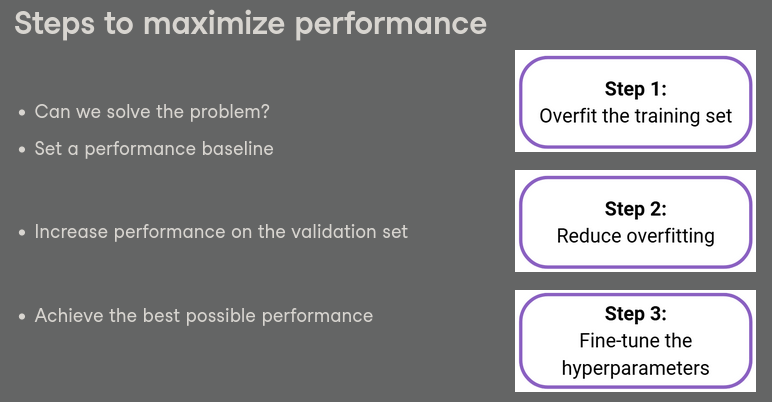


# Intermediate DL with PyTroch

## Training Robust Neural Networks

### PyTorch and object-oriented programming


In [4]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from torch.utils.data import Dataset, DataLoader
import torchmetrics

#### Pytorch Datasets and DataLoaders


In [5]:
class WaterDataset(Dataset):
    def __init__(self, csv_path):
        super().__init__()
        # Load data to pandas DataFrame
        df = pd.read_csv(csv_path)
        # Convert data to a NumPy array and assign to self.data
        self.data = df.to_numpy()
        
    # Implement __len__ to return the number of data samples
    def __len__(self):
        return self.data.shape[0]
    
    def __getitem__(self, idx):
        features = self.data[idx, :-1]
        # Assign last data column to label
        label = self.data[idx,-1]
        return features, label

In [6]:
# Create an instance of the WaterDataset
dataset_train = WaterDataset('water_potability.csv')

# Create a DataLoader based on dataset_train
dataloader_train = DataLoader(
    dataset_train,
    batch_size=2,
    shuffle=True,
)
# Get a batch of features and labels
features, labels = next(iter(dataloader_train))
print(features, labels)

tensor([[7.6943e+00, 1.8484e+02, 2.2673e+04, 5.7011e+00,        nan, 4.3963e+02,
         8.8577e+00, 6.4976e+01, 5.7072e+00],
        [7.6648e+00, 2.2358e+02, 2.0260e+04, 7.3854e+00, 3.5116e+02, 5.1005e+02,
         1.4205e+01, 7.3192e+01, 5.4817e+00]], dtype=torch.float64) tensor([1., 1.], dtype=torch.float64)


#### PyTorch Model


In [8]:
import torch.nn as nn
from torch.nn import init
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        # Define the three linear layers
        self.fc1 = nn.Linear(9,16)
        self.fc2 = nn.Linear(16,8)
        self.fc3 = nn.Linear(8,1)
        
    def forward(self, x):
        # Pass x through linear layers adding activations
        x = nn.functional.relu(self.fc1(x))
        x = nn.functional.relu(self.fc2(x))
        x = nn.functional.sigmoid(self.fc3(x))
        return x

### Optimizers, training, and evaluation

#### SGD optimizer

- Update depends on the learning rate and the momentum
- Simple and rarely used in practice

`optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)`

#### AdaGrad optimizer

- Adaptive learning rate method for each parameter
- Update depends on the learning rate and the sum of squared gradients
- Good for sparse data

`optimizer = optim.Adagrad(model.parameters(), lr=0.01)`

#### RMSProp optimizer

- update for each parameter based on the size of its previous gradients

`optimizer = optim.RMSprop(model.parameters(), lr=0.01)`

#### Adam optimizer

- The most used optimizer in deep learning
- Combines the advantages of both gradient momentum and RMSProp

`optimizer = optim.Adam(model.parameters(), lr=0.01)`


#### Model evaluation

- set up accuracy metric
- put model in eval mode and iterate over test data batches with no gradients
- pred data
- compute predicted class labels
- update metric with pred and labels


In [ ]:
import torch
from torchmetrics import Accuracy

# Set up binary accuracy metric
acc = Accuracy(task='binary')

net.eval()
with torch.no_grad():
    for features, labels in dataloader_test:
        # Get predicted probabilities for test data batch
        outputs = net(features)
        preds = (outputs >= 0.5).float()
        acc(preds, labels.view(-1, 1))

# Compute total test accuracy
test_accuracy = acc.compute()
print(f"Test accuracy: {test_accuracy}")

### Vanishing and exploding gradients


#### Weight initialization

Good initialization ensures:

- Variance of layer inputes = variance of layer outputs
- Variance of gradients the same before and after a layer

How to achieve this depends on the activation:

- For `ReLU` and similar, we can use Kaiming initialization
- For `Sigmoid` and `Tanh`, we can use Xavier initialization


In [9]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(9, 16)
        self.fc2 = nn.Linear(16, 8)
        self.fc3 = nn.Linear(8, 1)
        
        # Apply He initialization
        init.kaiming_uniform_(self.fc1.weight)
        init.kaiming_uniform_(self.fc2.weight)
        init.kaiming_uniform_(self.fc3.weight, nonlinearity="sigmoid")

    def forward(self, x):
        # Update ReLU activation to ELU
        x = nn.functional.elu(self.fc1(x))
        x = nn.functional.elu(self.fc2(x))
        x = nn.functional.sigmoid(self.fc3(x))
        return x

#### Activation functions


- Often used as the default activation
- It suffers from dying neurons in training when the input is negative, which can lead to zero gradients and prevent learning in those neurons.
- `ELU` is a smooth function that allows for negative outputs, which can help mitigate the dying ReLU problem. It has a parameter `alpha` that controls the value to which the function saturates for negative inputs.


#### Batch normalization

1. Normalizes the input of each layer to have zero mean and unit variance
2. Scale and shift normalized output with learnable parameters

Model learns optimal inputs distribution for each layer:

- Faster loss decrease
- Helps against unstable gradients


In [10]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(9, 16)
        # Add two batch normalization layers
        self.bn1 = nn.BatchNorm1d(16)
        self.fc2 = nn.Linear(16, 8)
        self.bn2 = nn.BatchNorm1d(8)
        self.fc3 = nn.Linear(8, 1)
        
        init.kaiming_uniform_(self.fc1.weight)
        init.kaiming_uniform_(self.fc2.weight)
        init.kaiming_uniform_(self.fc3.weight, nonlinearity="sigmoid")
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = nn.functional.elu(x)

        # Pass x through the second set of layers
        x = self.fc2(x)
        x = self.bn2(x)
        x = nn.functional.elu(x)

        x = nn.functional.sigmoid(self.fc3(x))
        return x

## Images & CNNs


In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchmetrics import Accuracy, Precision, Recall
from torchvision import datasets
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder


## Handling images with PyTorch


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jockeroika/clouds-photos")

print("Path to dataset files:", path)

Path to dataset files: /home/shk/.cache/kagglehub/datasets/jockeroika/clouds-photos/versions/1


### Compose


In [3]:
data_path = f"{path}/clouds_train"
test_path = f"{path}/clouds_test"

In [4]:
# Compose transformations
train_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((128,128)),
])

# Create Dataset using ImageFolder
dataset_train = ImageFolder(
    data_path,
    transform=train_transforms,
)

### Data augmentation in PyTorch


In [5]:
train_transforms = transforms.Compose([
    # Add horizontal flip and rotation
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(45),
    transforms.ToTensor(),
    transforms.Resize((128, 128)),
])

dataset_train = ImageFolder(
  data_path,
  transform=train_transforms,
)

dataloader_train = DataLoader(
  dataset_train, shuffle=True, batch_size=1
)

image, label = next(iter(dataloader_train))
# Reshape the image tensor
image = image.squeeze().permute(1, 2, 0) 
# Display the image
plt.imshow(image)
plt.show()

NameError: name 'plt' is not defined

## CNN

**Problem**: when dealing with images, we have a lot of features (pixels) and a small number of samples. This can lead to overfitting and poor generalization.

**Solution**: **Convolutional Neural Networks (CNNs)**

- Slide filters of parameters over the input
- At each posistion, perform convolution
- It compress a big image to smaller feature maps, which reduces the number of parameters and helps prevent overfitting
- Resulting feature map:
  - Preservers spatial patterns from input
  - uses fewer parameters than linear layer
- we can use many filters each filter = one feature map
- Filters are learned during training to extract relevant features for the task
- Apply activations to feature maps to introduce non-linearity
- All feature maps combined form the output of the convolutional layer, which can be fed into subsequent layers for further processing.
- in py we use `nn.Conv2d(in_channels, out_channels, kernel_size, stride=1, padding=0)` to create a convolutional layer.


### Convolution

In convolution we compute the dot product of input patch and the filter weights, then we sum the result and add a bias term to get a single output value. This process is repeated across the entire input image to produce a feature map. The filter weights are learned during training to extract relevant features from the input data.

### Zero-padding

- Add zeros around the border of the input image
- Preserves spatial dimensions after convolution
- Helps capture edge features and allows for deeper networks without reducing feature map size too quickly
- in py we can use `padding` parameter in `nn.Conv2d` to add zero-padding to the input image. For example, `nn.Conv2d(in_channels, out_channels, kernel_size, stride=1, padding=1)` will add a padding of 1 pixel around the input image.

### Max Pooling

We slide non-overlapping window over imput, at each position retain only the maximum value, used after convolutional layers to reduce spatial dimensions and capture dominant features. In PyTorch, you can use `nn.MaxPool2d(kernel_size, stride)` to apply max pooling to your feature maps. For example, `nn.MaxPool2d(kernel_size=2, stride=2)` will downsample the feature maps by a factor of 2, retaining the maximum value in each 2x2 window.


In [6]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ELU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ELU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Flatten()
        )
        self.classifier = nn.Linear(32 * 32 * 32, 1)

    def forward(self, x):
        x = self.feature_extractor(x)
        x = self.classifier(x)
        return x

- `feature_extractor`: (convolution,activation,pooling), repeated
- `classifier` : single layer with the number of taget classes as output size


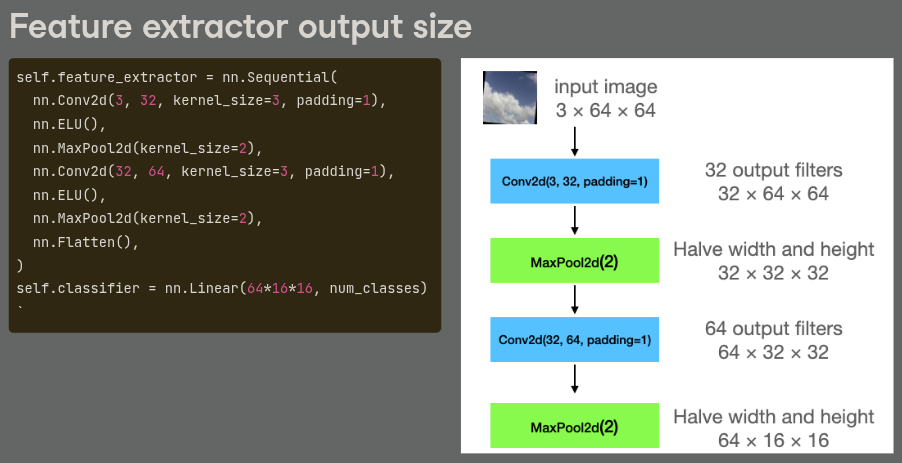


The convolutional layer
Convolutional layers are the basic building block of most computer vision architectures. Understanding why they're used and how they work is crucial for building image-processing neural networks.

Which of the following statements are true about convolutional layers?

- Convolutional layers preserve spatial information between their inputs and outputs.

- Adding zero-padding around the convolutional layer's input ensures that the pixels at the border receive as much attention as those located elsewhere in the feature map.

- Convolutional layers in general use fewer parameters than linear layers.


**Building convolutional networks**

You are on a team building a weather forecasting system. As part of the system, cameras will be installed at various locations to take pictures of the sky. Your task is to build a model to classify different cloud types in these pictures, which will help spot approaching weather fronts.

You decide to build a convolutional image classifier. The model will consist of two parts:

A feature extractor that learns a vector of features from the input image,
A classifier that predicts the image's class based on the learned features.
Both torch and torch.nn as nn have already been imported for you, so let's get to it!


In [7]:
class Net(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        # Define feature extractor
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ELU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ELU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Flatten(),
        )
        # Define classifier
        self.classifier = nn.Linear(64*16*16, num_classes)
    
    def forward(self, x):  
        # Pass input through feature extractor and classifier
        x = self.feature_extractor(x)
        x = self.classifier(x)
        return x

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

[]

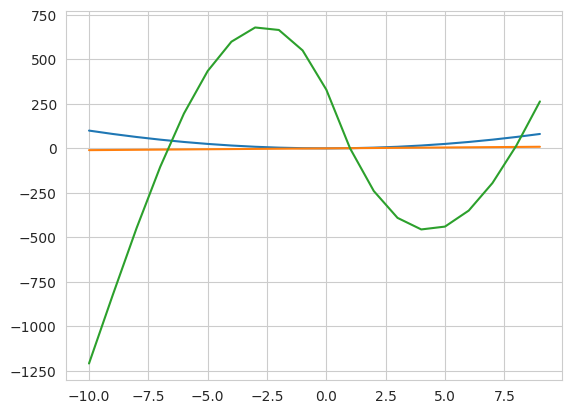

In [9]:
x = np.arange(-10,10,1)
y = x**2
w = x

conv = np.convolve(y,w,mode='same')
sns.set_style("whitegrid")
sns.lineplot(x=x, y=y)
sns.lineplot(x=x, y=w)
sns.lineplot(x=x, y=conv)

plt.plot()

## Training image classifiers

### The Real Data Augmetation

Data augmentation is a powerful technique to increase the diversity of your training data by applying random transformations to the input images. This helps prevent overfitting and improves the generalization of your model, But it is not that bright there is a bad part of it.

e.g. you have a dataset of handwritten chars, you can apply random rotations, shifts, and flips to create new training samples. However, if the transformations are too extreme or unrealistic, they can introduce noise and make the model learn irrelevant features, leading to worse performance on real-world data.

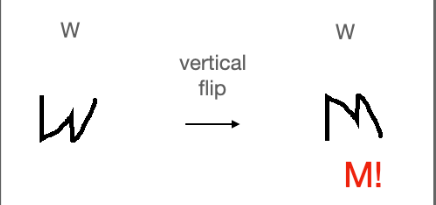

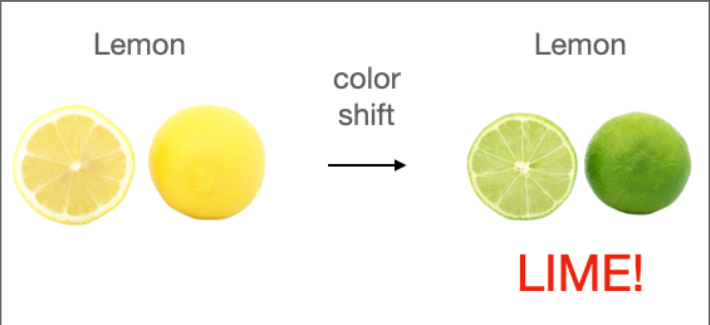

so:
- Sometimes augmentations can impact the label
- Augmentation could be depedent on the task

Features shape: torch.Size([16, 3, 64, 64])
Labels shape: torch.Size([16])


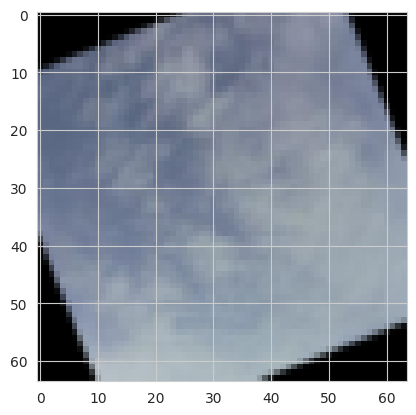

In [10]:
# Define transforms
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(45),
    transforms.RandomAutocontrast(),
    transforms.ToTensor(),
    transforms.Resize((64,64)),
])

dataset_train = ImageFolder(
  data_path,
  transform=train_transforms,
)
dataloader_train = DataLoader(
  dataset_train, shuffle=True, batch_size=16
)

# print samples
features, labels = next(iter(dataloader_train))
print("Features shape:", features.shape)
print("Labels shape:", labels.shape)
plt.imshow(features[0].permute(1,2,0))
plt.show()

In [11]:
num_classes = len(dataset_train.classes)

#### train

In [12]:
# Define the model
net = Net(num_classes)
# Define the loss function
criterion = nn.CrossEntropyLoss()
# Define the optimizer
optimizer = optim.Adam(net.parameters(),lr=0.001)

for epoch in range(3):
    running_loss = 0.0
    # Iterate over training batches
    for images, labels in dataloader_train:
        optimizer.zero_grad()
        outputs = net(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    epoch_loss = running_loss / len(dataloader_train)
    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}")

Epoch 1, Loss: 1.8638
Epoch 2, Loss: 1.6041
Epoch 3, Loss: 1.4336


## Evaluating image classifiers


### Precision & Recall

$ \text{Precision} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Positives}} $

$ \text{Recall} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Negatives}} $

**Precision**: Is the Fraction of correct positive predictions

**Recall**: Is the Fraction of correct positive predictions out of all actual positives

### Averaging multi-class metrics

- With n classes, we have n precision and n recall values, one for each class
- We can analyze them per-class, or aggregate:
    - **Micro avrage**: Compute global counts of true positives, false positives, and false negatives across all classes, then calculate precision and recall from these totals. This method gives equal weight to each individual prediction, regardless of class.
    - **Macro average**: Calculate precision and recall for each class independently, then take the average of these values across all classes. This method gives equal weight to each class, regardless of the number of samples in each class.
    - **Weighted average**: Calculate precision and recall for each class independently, then take the average of these values across all classes, weighted by the number of samples in each class. This method gives more weight to classes with more samples, which can provide a more balanced evaluation when class distribution is imbalanced.

In [13]:
from torchmetrics import Recall

recall_per_class = Recall(task="multiclass", num_classes=num_classes, average=None)
recall_micro = Recall(task="multiclass", num_classes=num_classes, average='micro')
recall_macro = Recall(task="multiclass", num_classes=num_classes, average='macro')
recall_weighted = Recall(task="multiclass", num_classes=num_classes, average='weighted')

#### When to use each?

- **Micro**: when the data is highly unbalanced
- **Macro**: treats all the classes equally regardless of the number of samples in each class
- **Weighted**: Weighted averaging is a good choice when class imbalance is a concern and you consider errors in larger classes as more important.

### Evaluation diagram

1. Import and define precision and recall metrics
2. Iterate over test examples with no grad
3. for each batch get the model outputs, compute predicted class labels
4. pass it to metric functions along with the labels

In [14]:
dataset_test = ImageFolder(
  test_path,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Resize((64,64)),
    ]))

dataloader_test = DataLoader(dataset_test, shuffle=False, batch_size=16)

In [15]:
# Define metrics
metric_precision = Precision(task='multiclass', num_classes=7, average='micro')
metric_recall = Recall(task='multiclass', num_classes=7, average='micro')
acc = Accuracy(task='multiclass', num_classes=7)
net.eval()
with torch.no_grad():
    for images, labels in dataloader_test:
        outputs = net(images)
        _, preds = torch.max(outputs, 1)
        metric_precision(preds, labels)
        metric_recall(preds, labels)
        acc(preds, labels)
precision = metric_precision.compute()
recall = metric_recall.compute()
accuracy = acc.compute()
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"Accuracy: {accuracy}")

Precision: 0.4938271641731262
Recall: 0.4938271641731262
Accuracy: 0.4938271641731262


In [16]:
# Define precision metric
metric_precision = Precision(
    task="multiclass", num_classes=7, average=None
)

net.eval()
with torch.no_grad():
    for images, labels in dataloader_test:
        outputs = net(images)
        _, preds = torch.max(outputs, 1)
        metric_precision(preds, labels)
precision = metric_precision.compute()

# Get precision per class
precision_per_class = {
    k: precision[v].item()
    for k, v 
    in dataset_test.class_to_idx.items()
}
print(precision_per_class)

{'cirriform clouds': 0.0, 'clear sky': 0.5779816508293152, 'cumulonimbus clouds': 0.8571428656578064, 'cumulus clouds': 0.5614035129547119, 'high cumuliform clouds': 0.3678756356239319, 'stratiform clouds': 0.5714285969734192, 'stratocumulus clouds': 0.5714285969734192}


## RNN
### Handling sequences with PyTorch
In this section, we will explore how to handle sequential data using PyTorch. Sequential data, such as time series, text, or audio, requires special handling because the order of the data points matters. We will cover how to prepare sequential data for training and how to use Recurrent Neural Networks (RNNs) to model such data effectively.

**How it works**
- RNNs process sequential data by maintaining a hidden state that captures information from previous time steps.

In [ ]:
import numpy as np

def create_sequences(df, seq_length):
    xs, ys = [], []
    # Iterate over data indices
    for i in range(len(df)-seq_length):
      	# Define inputs
        x = df.iloc[i:i+seq_length, 1]
        # Define target
        y = df.iloc[i+seq_length, 1]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

In [ ]:
import torch
from torch.utils.data import TensorDataset

# Use create_sequences to create inputs and targets
X_train, y_train = create_sequences(train_data,24*4)
print(X_train.shape, y_train.shape)

# Create TensorDataset
dataset_train = TensorDataset(
    torch.tensor(X_train),
    torch.tensor(y_train),
)
print(len(dataset_train))

## Recurrent Neural Networks

**Steps**:

- Define model class with `__init__` method
- Define Recurrent layer, `self.rnn`
- Define linear layer, `self.fc`
- In `forward()`, initialize first hidden state to zeros
- Pass input and first hidden state through RNN layer
- Select last RNN's output pass it through linear layer

In [ ]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        # Define RNN layer
        self.rnn = nn.RNN(
            input_size=1,
            hidden_size=32,
            num_layers=2,
            batch_first=True,
        )
        self.fc = nn.Linear(32, 1)

    def forward(self, x):
        # Initialize first hidden state with zeros
        h0 = torch.zeros(2, x.size(0), 32)
        # Pass x and h0 through recurrent layer
        out, _ = self.rnn(x,h0)

## LSTM and GRU cells

### RNN cell

RNN cell accept two inputs `h` and `x` and produces two outputs `h'` and `y`. The hidden state `h` captures information from previous time steps, while the input `x` represents the current data point. The RNN cell processes these inputs to produce an updated hidden state `h'`, which is then used to generate the output `y`. This structure allows RNNs to model sequential data effectively by maintaining a memory of past information through the hidden state.

### LSTM cell

LSTM (Long Short-Term Memory) cells accept three inputs: the hidden state `h` for short term memory, the cell state `c` for long term memory, and the input `x`. The LSTM cell produces two outputs: the updated hidden state `h'` and the updated cell state `c'`. The hidden state `h'` captures information relevant to the current time step, while the cell state `c'` retains information over longer sequences. This architecture allows LSTMs to effectively model long-term dependencies in sequential data, making them suitable for tasks like language modeling and time series prediction.

**LSTM** have three gates:
- **Forget Gate**: Decides what information to discard from the cell state.
- **Input Gate**: Learns new things it sees the x and h and then decide what to add to the cell state.
- **Output Gate**: Decides what to output based on the cell state and hidden state

**بكلمة واحدة: LSTM**

 **تتحكم بإيش تنسى وإيش تتذكر وإيش تطلع.**

In [ ]:
import torch
import torch.nn as nn

class Net(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        # Define lstm layer
        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=32,
            num_layers=2,
            batch_first=True,
        )
        self.fc = nn.Linear(32, 1)

    def forward(self, x):
        h0 = torch.zeros(2, x.size(0), 32)
        # Initialize long-term memory
        c0 = torch.zeros(2,x.size(0),32)
        # Pass all inputs to lstm layer
        out, _ = self.lstm(x,(h0,c0))
        out = self.fc(out[:, -1, :])
        return out

### GRU cell

**GRU** (Gated Recurrent Unit) cells are a simplified version of LSTM cells that combine the forget and input gates into a single update gate. GRUs accept two inputs: the hidden state `h` and the input `x`, and produce one output: the updated hidden state `h'`. GRU have no output gate and no cell state, they only have hidden state. GRUs are computationally more efficient than LSTMs while still being effective at capturing long-term dependencies in sequential data, making them a popular choice for many applications.

**GRU** have two gates:
- **Update Gate**: Combines the functions of the forget and input gates in LSTM, deciding what information to keep and what to update in the hidden state.
- **Reset Gate**: Determines how much of the past information to forget when computing the new hidden state, and balancing the past and the present


In [ ]:
import torch
import torch.nn as nn

class Net(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        # Define GRU layer
        self.gru = nn.GRU(
            input_size=1,
            hidden_size=32,
            num_layers=2,
            batch_first=True,
        )
        self.fc = nn.Linear(32, 1)

    def forward(self, x):
        h0 = torch.zeros(2, x.size(0), 32)
        # Pass all inputs to GRU layer
        out, _ = self.gru(x,h0)
        out = self.fc(out[:, -1, :])
        return out

### WHEN TO USE??

- RNN: is not used much because of the vanishing gradient problem and short term memory
- GRU is simpler than LSTM, we can use it when we have a small dataset and we want to train faster, but if we have a large dataset and we want to capture long term dependencies we can use LSTM
- Try both and compare

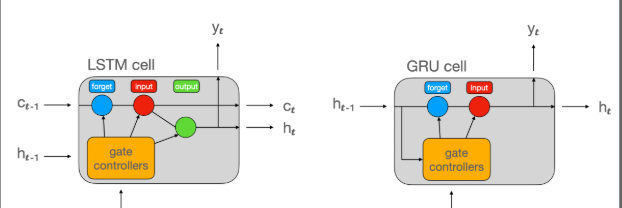

## Training RNNs
### Expanding tensors
- RNNs expect a 3D input of shape (batch_size, sequence_length, input_size)
- Data loader gives us a 2D tensor of shape (batch_size, input_size)
- We need to add a dimension for sequence_length, which is 1 in this case
- We can use `unsqueeze` to add this dimension: `x = x.unsqueeze(1)` to make it (batch_size, 1, input_size)

## Evaluating RNNs
- Set up accuracy metric
- Iterate through test data batches with no gradients
- Reshape model inputs `.view(batch_size,seq_length, num_features)`
- Pass inputs through model to get outputs
- Sqeeze model outputs to get predicted class labels
- Update metric with predicted and true labels


In [ ]:
# Training
net = Net()
# Set up MSE loss
criterion = nn.MSELoss()
optimizer = optim.Adam(
  net.parameters(), lr=0.0001
)

for epoch in range(3):
    for seqs, labels in dataloader_train:
        # Reshape model inputs
        seqs = seqs.view(seqs.size(0),seqs.size(1),1)
        # Get model outputs
        outputs = net(seqs)
        # Compute loss
        loss = criterion(outputs,labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}, Loss: {loss.item()}")

In [ ]:
# Evaluating

# Define MSE metric
mse = torchmetrics.MeanSquaredError()

net.eval()
with torch.no_grad():
    for seqs, labels in dataloader_test:
        seqs = seqs.view(32, 96, 1)
        # Pass seqs to net and squeeze the result
        outputs = net(seqs).squeeze()
        mse(outputs, labels)

# Compute final metric value
test_mse = mse.compute()
print(f"Test MSE: {test_mse}")

In [ ]:
import pandas as pd

pd.read_csv